# Pipeline de Clusterização de Clientes - Olist
Este notebook executa o pipeline completo de segmentação de clientes utilizando PCA para redução de dimensionalidade, seguido pelos algoritmos K-Means e GMM.

In [7]:
# Configuração para recarregar os arquivos .py automaticamente caso você os altere
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importando apenas o motor de processamento e modelagem no início
from src.processamento import carregar_e_agregar_dados, tratar_e_padronizar
from src.modelagem import rodar_kmeans, rodar_gmm, comparar_modelos, analisar_perfis

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Passo 1: Consolidação dos Dados
Carregando os arquivos brutos da pasta `dados/` e agregando as informações por cliente único (`customer_unique_id`).

In [8]:
caminho_dados = 'dados/'
df_clientes = carregar_e_agregar_dados(caminho_dados)

print(f"Total de clientes unificados na base: {df_clientes.shape[0]}")
df_clientes.head()

Total de clientes unificados na base: 94990


,customer_unique_id,recencia,frequencia,monetario,parcelas_medias,pct_boleto,pct_cartao_credito,frete_total,review_medio,escreveu_comentario,tempo_entrega_medio,pct_compras_fds,is_sudeste,peso_medio_produtos,qtd_itens_total,gasto_casa_decoracao,gasto_saude_beleza,gasto_esporte_lazer,gasto_tecnologia,gasto_moda_acessorios
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,8.0,0.0,1.0,12.00,5.0,1.0,6.0,0.0,1,1500.0,1.0,129.9,0.0,0.0,0.00,0.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,1.0,0.0,1.0,8.29,4.0,0.0,3.0,0.0,1,375.0,1.0,0.0,18.9,0.0,0.00,0.0
2,0000f46a3911fa3c0805444483337064,542,1,86.22,8.0,0.0,1.0,17.22,3.0,0.0,25.0,0.0,0,1500.0,1.0,0.0,0.0,0.0,0.00,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,4.0,0.0,1.0,17.63,4.0,1.0,20.0,0.0,0,150.0,1.0,0.0,0.0,0.0,25.99,0.0
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89,6.0,0.0,1.0,16.89,5.0,0.0,13.0,0.0,1,6050.0,1.0,0.0,0.0,0.0,180.00,0.0


## Passo 2: Pré-processamento e Padronização
Definição das features que alimentarão o modelo, aplicação de log para corrigir assimetrias e padronização com `StandardScaler`.

In [9]:
features = [col for col in df_clientes.columns if col != 'customer_unique_id']

df_tratado = df_clientes[features].copy()
colunas_log = [
    'recencia', 'frequencia', 'monetario', 'frete_total', 
    'tempo_entrega_medio', 'peso_medio_produtos', 'qtd_itens_total', 
    'comprimento_descricao_medio', 'qtd_vendedores_total'
]

for col in colunas_log:
    if col in df_tratado.columns:
        df_tratado[col] = np.log1p(np.clip(df_tratado[col], 0, None))

print(f"Total de {len(features)} atributos mistos preparados para o FAMD.")

Total de 19 atributos mistos preparados para o FAMD.


## Passo 3: Análise de Dimensionalidade (FAMD)
Ajustando o FAMD para entender quanta variância cada componente consegue explicar.

[FAMD] Dados reduzidos com sucesso para 12 eixos.

[💡 ANÁLISE AUTOMÁTICA] Método aplicado: Método do Cotovelo (Desaceleração do Ganho Marginal)
👉 O número ideal de componentes para sua clusterização é: 5 componentes.



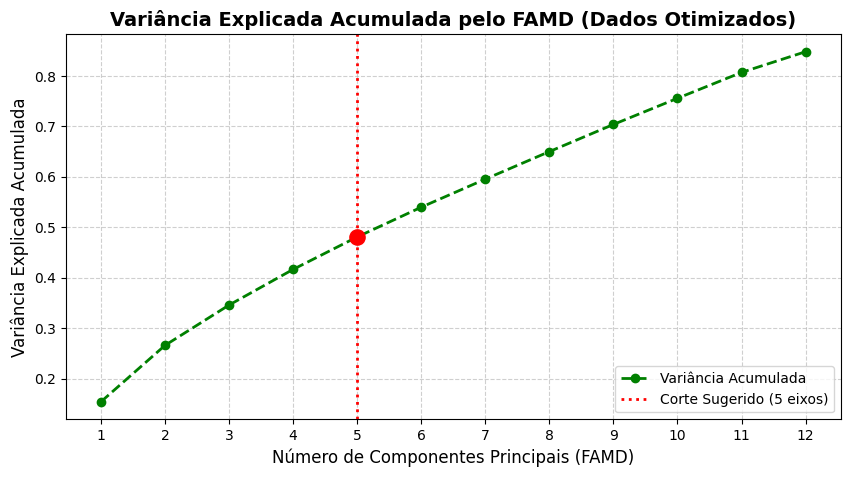

Formato da matriz total gerada pelo FAMD: (94990, 12)


In [13]:
## Passo 3: Análise de Dimensionalidade (FAMD) com Escolha Automatizada
from src.dimensionalidade import aplicar_famd, encontrar_melhor_k_famd, plotar_variancia_famd

# Ajustamos o modelo inicial abrindo espaço para 12 componentes principais mistos
n_componentes_famd = 12
famd_modelo, dados_pca_total = aplicar_famd(df_tratado, features, n_componentes=n_componentes_famd)

# EXECUTANDO A TÉCNICA AUTOMÁTICA: O Python avalia os autovalores e as derivadas de ganho
n_componentes_finais = encontrar_melhor_k_famd(famd_modelo)

# Plota o gráfico exibindo exatamente onde a linha vermelha de corte deve ficar
plotar_variancia_famd(famd_modelo, n_recomendado=n_componentes_finais)

print(f"Formato da matriz total gerada pelo FAMD: {dados_pca_total.shape}")

### Redução para os Componentes Selecionados
Com base no gráfico acima, escolha o número de componentes (ex: 3 componentes) para transformar nossos dados.

In [14]:
# Fatiamos dinamicamente com base no cálculo estatístico automático anterior
dados_pca = dados_pca_total[:, :n_componentes_finais]

print(f"Dados prontos para a clusterização. Novo formato com FAMD: {dados_pca.shape}")
# Irá exibir o corte exato sugerido pelo algoritmo (ex: (94990, 4) ou (94990, 3))

Dados prontos para a clusterização. Novo formato com FAMD: (94990, 5)


## Passo 4: Agrupamento com K-Means
Execução do loop para avaliação de hiperparâmetros (Inércia e Silhueta). Ajuste do modelo final com o `k_escolhido`.

In [ ]:
# O código vai plotar o Cotovelo e a Silhueta automaticamente
# Defina o k_escolhido após analisar os gráficos gerados por essa função
kmeans_modelo, labels_kmeans = rodar_kmeans(dados_pca, k_max=10, k_escolhido=4)

# Salvando o resultado no nosso dataframe principal
df_clientes['cluster_kmeans'] = labels_kmeans

## Passo 5: Agrupamento com GMM (Gaussian Mixture Models)
Avaliação dos critérios de informação BIC e AIC para escolher o número de componentes probabilísticos.

In [ ]:
# O código vai plotar as curvas de BIC e AIC automaticamente
gmm_modelo, labels_gmm = rodar_gmm(dados_pca, n_max=10, n_escolhido=4)

# Salvando os rótulos do GMM e a probabilidade de pertencer ao cluster principal
df_clientes['cluster_gmm'] = labels_gmm
df_clientes['prob_cluster'] = gmm_modelo.predict_proba(dados_pca).max(axis=1)

## Passo 6: Comparação Estatística entre K-Means e GMM
Análise de cruzamento de grupos (Matriz de Contingência), ARI e NMI para checar a concordância dos dois modelos.

In [ ]:
comparar_modelos(df_clientes['cluster_kmeans'], df_clientes['cluster_gmm'])

## Passo 7: Perfilamento de Negócio
Análise das médias reais de faturamento, recência, frete e avaliações para criar as personas de cada cluster.

In [ ]:
print("====== PERFIL DOS CLUSTERS - K-MEANS ======")
perfis_kmeans = analisar_perfis(df_clientes, agrupado_por='cluster_kmeans')
display(perfis_kmeans)

print("\n====== PERFIL DOS CLUSTERS - GMM ======")
perfis_gmm = analisar_perfis(df_clientes, agrupado_por='cluster_gmm')
display(perfis_gmm)